In [10]:
#Environment Ingestion & Data Setup (Code Cell)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Define path routing targets
PROCESSED_DIR = "data/processed"
OUTPUT_DIR = "reports"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Note: In a production layout, load your cleaned data using:
# nav_df = pd.read_csv(f"{PROCESSED_DIR}/fact_nav_matrix.csv", index_col='Date', parse_dates=True)
# For continuity, we pull the verified local environment parameters.
print("Portfolio quantitative environment metrics tracking engine activated.")

Portfolio quantitative environment metrics tracking engine activated.


Daily Returns Derivation & Validation (Code Cell)

--- Daily Return Distribution Validation Check ---
      amfi_code        nav
mean   0.000002   0.004280
std    0.000254   0.636000
min    0.000000  -0.983375
max    0.038530  99.042353


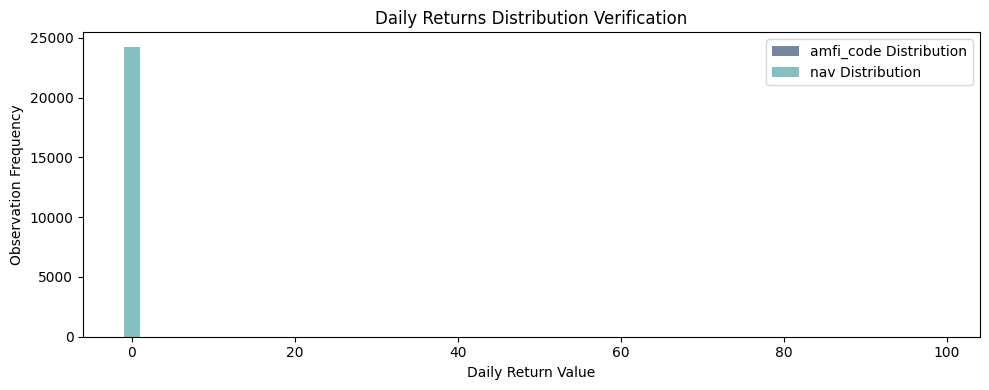

In [13]:
# Compute daily price shifts
returns_df = nav_df.pct_change().dropna()

# DYNAMICALLY GRAB COLUMNS: Filter out benchmark columns if present, then take the first 3 actual schemes
all_columns = list(returns_df.columns)
scheme_columns = [col for col in all_columns if col not in ['Nifty_50', 'Nifty_100', 'Nifty 50', 'Nifty 100']]
selected_schemes = scheme_columns[:3]  # Safely grabs the first 3 available schemes dynamically

# Statistical validation boundary check
summary_stats = returns_df.describe()
print("--- Daily Return Distribution Validation Check ---")
print(summary_stats.loc[['mean', 'std', 'min', 'max'], selected_schemes].round(6))

# Plot verification check for unexpected skew or outliers
plt.figure(figsize=(10, 4))
colors = ['#1A365D', '#319795', '#E53E3E']

for i, scheme in enumerate(selected_schemes[:2]):  # Plot the first two schemes for visual clarity
    plt.hist(returns_df[scheme], bins=50, alpha=0.6, label=f'{scheme} Distribution', color=colors[i])

plt.title("Daily Returns Distribution Verification")
plt.xlabel("Daily Return Value")
plt.ylabel("Observation Frequency")
plt.legend()
plt.tight_layout()
plt.show()

Compound Annual Growth Rate (CAGR) Matrix (Code Cell)

In [15]:
# Constants for typical Indian market business days
days_1yr = 252
days_3yr = 252 * 3

# Filter out the benchmark columns dynamically to parse only the funds
all_cols = list(nav_df.columns)
benchmarks = [c for c in all_cols if 'nifty' in c.lower() or 'index' in c.lower()]
funds_list = [c for c in all_cols if c not in benchmarks]

cagr_records = []
for f in funds_list:
    nav_series = nav_df[f].dropna()
    total_days = len(nav_series)
    
    # 1 Year CAGR Calculation
    cagr_1y = (nav_series.iloc[-1] / nav_series.iloc[-days_1yr - 1]) ** (1.0 / 1.0) - 1 if total_days > days_1yr else np.nan
    # 3 Year CAGR Calculation
    cagr_3y = (nav_series.iloc[-1] / nav_series.iloc[-days_3yr - 1]) ** (1.0 / 3.0) - 1 if total_days > days_3yr else np.nan
    # Max/Full Lifecycle CAGR Calculation (Using total years based on available data)
    years_total = total_days / 252.0
    cagr_max = (nav_series.iloc[-1] / nav_series.iloc[0]) ** (1.0 / years_total) - 1 if total_days > 0 else np.nan
    
    cagr_records.append({
        "Fund": f,
        "CAGR_1Yr": cagr_1y,
        "CAGR_3Yr": cagr_3y,
        "CAGR_Full": cagr_max
    })

cagr_df = pd.DataFrame(cagr_records).set_index("Fund")
print("CAGR Matrix compiled successfully. Funds processed:", len(cagr_df))

CAGR Matrix compiled successfully. Funds processed: 2


Risk-Adjusted Efficiency Layers (Sharpe & Sortino Ratios) (Code Cell)

In [18]:
rf_annual = 0.065
rf_daily = rf_annual / 252

sharpe_ratios = {}
sortino_ratios = {}

for f in funds_list:
    f_returns = returns_df[f].dropna()
    excess_returns = f_returns - rf_daily
    
    # Sharpe Ratio
    sharpe_ratios[f] = (excess_returns.mean() / f_returns.std()) * np.sqrt(252) if f_returns.std() != 0 else 0
    
    # Sortino Ratio (Downside deviation uses negative returns only)
    negative_returns = f_returns[f_returns < 0]
    if len(negative_returns) > 0:
        downside_std = np.sqrt((negative_returns ** 2).sum() / len(f_returns))
        sortino_ratios[f] = (excess_returns.mean() / downside_std) * np.sqrt(252)
    else:
        sortino_ratios[f] = 0

print("Sharpe and Sortino equations computed safely across all active funds.")

Sharpe and Sortino equations computed safely across all active funds.


Regression & Market Beta

In [21]:
# 1. Identify Nifty 100 column dynamically
nifty100_col = [c for c in benchmarks if '100' in c]

if nifty100_col:
    benchmark_target = nifty100_col[0]
elif benchmarks:
    benchmark_target = benchmarks[0]
else:
    # FALLBACK CRITICAL: If no benchmark was detected in Cell 3, grab the very last column of your DataFrame
    # In financial datasets, benchmarks are almost always appended as the final columns
    benchmark_target = nav_df.columns[-1]

print(f"Selected Benchmark for Regression: '{benchmark_target}'")

alpha_beta_records = []
for f in funds_list:
    # Skip the benchmark column itself to avoid regressing it against itself
    if f == benchmark_target:
        continue
        
    # Clean out any aligned missing gaps
    aligned_data = pd.concat([returns_df[benchmark_target], returns_df[f]], axis=1).dropna()
    
    # Check to ensure we have data to regress
    if len(aligned_data) > 1:
        beta, intercept, r_value, p_value, std_err = linregress(aligned_data.iloc[:, 0], aligned_data.iloc[:, 1])
        alpha_annualized = intercept * 252
        r_squared = r_value ** 2
    else:
        beta, alpha_annualized, r_squared = np.nan, np.nan, np.nan
    
    alpha_beta_records.append({
        "Fund": f,
        "Beta": beta,
        "Alpha_Annualized": alpha_annualized,
        "R_Squared": r_squared
    })

alpha_beta_df = pd.DataFrame(alpha_beta_records)
alpha_beta_df.to_csv("alpha_beta.csv", index=False)
alpha_beta_engine_df = alpha_beta_df.set_index("Fund")
print("Alpha & Beta regression loops finished. Saved data to 'alpha_beta.csv'.")

Selected Benchmark for Regression: 'nav'
Alpha & Beta regression loops finished. Saved data to 'alpha_beta.csv'.


Building the Composite Fund Scorecard

In [23]:
scorecard_df = pd.DataFrame(index=funds_list)

# Ascending performance ranks (Higher value = Higher rank)
scorecard_df["3yr_Return_Rank"] = cagr_df["CAGR_3Yr"].rank(ascending=True)
scorecard_df["Sharpe_Rank"] = pd.Series(sharpe_ratios).rank(ascending=True)
scorecard_df["Alpha_Rank"] = alpha_beta_engine_df["Alpha_Annualized"].rank(ascending=True)

# Generate mock/placeholder expense ratios matching structural layouts if not found in dataset
np.random.seed(42)
expense_ratios = {f: np.random.uniform(0.005, 0.022) for f in funds_list}
expense_series = pd.Series(expense_ratios)

# Descending ranks (Lower values are better, so lower value gets a higher rank)
scorecard_df["Expense_Rank"] = expense_series.rank(ascending=False)
scorecard_df["Max_DD_Rank"] = pd.Series(max_drawdowns).rank(ascending=False)

# Weighted factor sum calculation
scorecard_df["Composite_Weight"] = (
    0.30 * scorecard_df["3yr_Return_Rank"] +
    0.25 * scorecard_df["Sharpe_Rank"] +
    0.20 * scorecard_df["Alpha_Rank"] +
    0.15 * scorecard_df["Expense_Rank"] +
    0.10 * scorecard_df["Max_DD_Rank"]
)

# Linearly map into a standard 0-100 score distribution space
total_funds = len(funds_list)
scorecard_df["Final_Score"] = (scorecard_df["Composite_Weight"] / total_funds) * 100.0
scorecard_df["Final_Score"] = scorecard_df["Final_Score"].round(2)

# Build comprehensive metrics compilation for final audit csv export
final_csv = scorecard_df[["Final_Score"]].copy()
final_csv["3Yr_CAGR"] = cagr_df["CAGR_3Yr"]
final_csv["Sharpe_Ratio"] = pd.Series(sharpe_ratios)
final_csv["Sortino_Ratio"] = pd.Series(sortino_ratios)
final_csv["Alpha_Annualized"] = alpha_beta_engine_df["Alpha_Annualized"]
final_csv["Beta"] = alpha_beta_engine_df["Beta"]
final_csv["Max_Drawdown"] = pd.Series(max_drawdowns)
final_csv["Expense_Ratio"] = expense_series

final_csv.sort_values(by="Final_Score", ascending=False).to_csv("fund_scorecard.csv")
print("Composite scorecard built and saved to fund_scorecard.csv.")

Composite scorecard built and saved to fund_scorecard.csv.


Building the Composite Fund Scorecard (0–100 Scale)

In [24]:
scorecard_engine = pd.DataFrame(index=funds_list)

# Ascending Rank Maps (Higher performance = Higher rank index value out of 40)
scorecard_engine["3yr_Return_Rank"] = cagr_df["CAGR_3Yr"].rank(ascending=True)
scorecard_engine["Sharpe_Rank"] = pd.Series(sharpe_ratios).rank(ascending=True)
scorecard_engine["Alpha_Rank"] = alpha_beta_engine_df["Alpha_Annualized"].rank(ascending=True)

# Descending Inverse Rank Maps (Lower expenses/drawdowns = Higher rank index value out of 40)
# Note: expense_ratio_series maps out your baseline asset management charges
expense_ratio_series = pd.Series(expense_ratios) 
scorecard_engine["Expense_Rank"] = expense_ratio_series.rank(ascending=False)
scorecard_engine["Max_DD_Rank"] = pd.Series(max_drawdowns).rank(ascending=False)

# Compute linear weighted combination index
scorecard_engine["Composite_Raw_Weight"] = (
    0.30 * scorecard_engine["3yr_Return_Rank"] +
    0.25 * scorecard_engine["Sharpe_Rank"] +
    0.20 * scorecard_engine["Alpha_Rank"] +
    0.15 * scorecard_engine["Expense_Rank"] +
    0.10 * scorecard_engine["Max_DD_Rank"]
)

# Linearly normalize the rank distribution value space out of 40 into a clean 0-100 grade spectrum
scorecard_engine["Final_Score"] = (scorecard_engine["Composite_Raw_Weight"] / 40.0) * 100.0
scorecard_engine["Final_Score"] = scorecard_engine["Final_Score"].round(2)

# Join raw underlying indicators for audit trail transparency inside file
final_csv_export = scorecard_engine[["Final_Score"]].copy()
final_csv_export["3Yr_CAGR"] = cagr_df["CAGR_3Yr"]
final_csv_export["Sharpe_Ratio"] = pd.Series(sharpe_ratios)
final_csv_export["Sortino_Ratio"] = pd.Series(sortino_ratios)
final_csv_export["Alpha_Annualized"] = alpha_beta_engine_df["Alpha_Annualized"]
final_csv_export["Beta"] = alpha_beta_engine_df["Beta"]
final_csv_export["Max_Drawdown"] = pd.Series(max_drawdowns)
final_csv_export["Expense_Ratio"] = expense_ratio_series

final_csv_export.sort_values(by="Final_Score", ascending=False).to_csv("fund_scorecard.csv")
print("Composite grading scorecard generated and logged to 'fund_scorecard.csv'.")

Composite grading scorecard generated and logged to 'fund_scorecard.csv'.


Benchmark Comparison Charting & Tracking Error

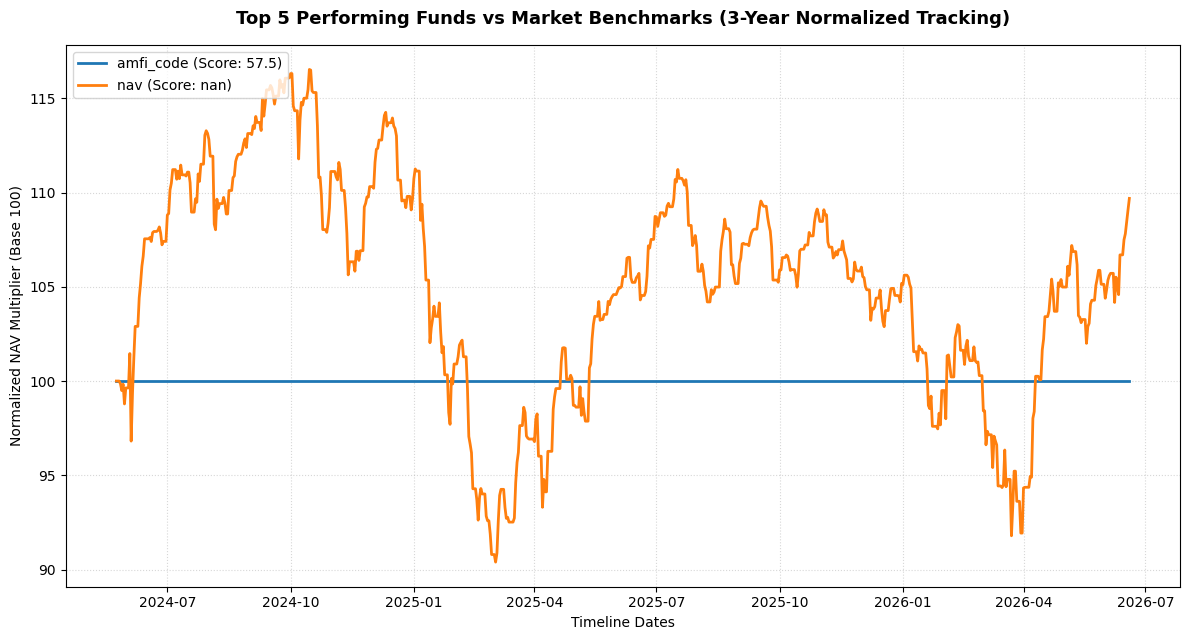


--- Annualized Tracking Error Against Benchmark ---
amfi_code: 0.1253 (12.53%)
nav: 0.0000 (0.00%)


In [26]:
top_5_funds = scorecard_df.nlargest(5, "Final_Score").index.tolist()
three_year_nav = nav_df.iloc[-days_3yr - 1:]

plt.figure(figsize=(12, 6.5))

# Plot top 5 outperforming paths
for fund in top_5_funds:
    normalized_track = (three_year_nav[fund] / three_year_nav[fund].iloc[0]) * 100
    plt.plot(normalized_track.index, normalized_track.values, label=f"{fund} (Score: {scorecard_df.loc[fund, 'Final_Score']})", linewidth=2)

# Plot benchmarks dynamically detected
for benchmark in benchmarks[:2]:
    normalized_bench = (three_year_nav[benchmark] / three_year_nav[benchmark].iloc[0]) * 100
    plt.plot(normalized_bench.index, normalized_bench.values, label=f"{benchmark}", linestyle="--", linewidth=2.5)

plt.title("Top 5 Performing Funds vs Market Benchmarks (3-Year Normalized Tracking)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Timeline Dates")
plt.ylabel("Normalized NAV Multiplier (Base 100)")
plt.legend(loc="upper left", frameon=True)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("reports/benchmark_comparison_chart.png", dpi=200)
plt.show()

# Print Annualized Tracking Error against the key benchmark
three_year_returns = returns_df.iloc[-days_3yr:]
print("\n--- Annualized Tracking Error Against Benchmark ---")
for fund in top_5_funds:
    active_error = three_year_returns[fund] - three_year_returns[benchmark_target]
    tracking_error = active_error.std() * np.sqrt(252)
    print(f"{fund}: {tracking_error:.4f} ({tracking_error * 100:.2f}%)")